In [1]:
%matplotlib inline 

In [2]:
# Imports
import os
import pathlib
import urllib.request

# Site name for Salvus Flow. Uses env var if available, otherwise falls back to local site name.
SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_weighted_denser" 

# Conservative default to reduce license-seat demand during unstable license-server periods.
RANKS_PER_JOB = 4


def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    """Fail fast if licensing endpoint is unreachable to avoid long hanging jobs."""
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). Retry later or check network/VPN. Original error: {exc}"
        ) from exc


# # Add code to keep .gitignore updated to ignore salvus files
# gitignore_path = pathlib.Path("..") / ".gitignore"
# with open(gitignore_path, "r+") as f:
#     contents = f.read()
#     if PROJECT_DIR not in contents:
#         f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import salvus.flow.simple_config as sc
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output
import salvus.flow.api

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.16 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion()

[2026-06-19 14:39:20,275] INFO: Loading project from simulation_wavefield_custom_stf_weighted_denser.


Time step between sources: 0.5556 s
t_sim length: 28823 samples, duration: 2.882 s
Source 0 at x=30.0 m | delay=0.0800 s | weight= xx:0.8745,  yy: 0.6560, xy: 0.5206 | stf_start_time=0.000000s


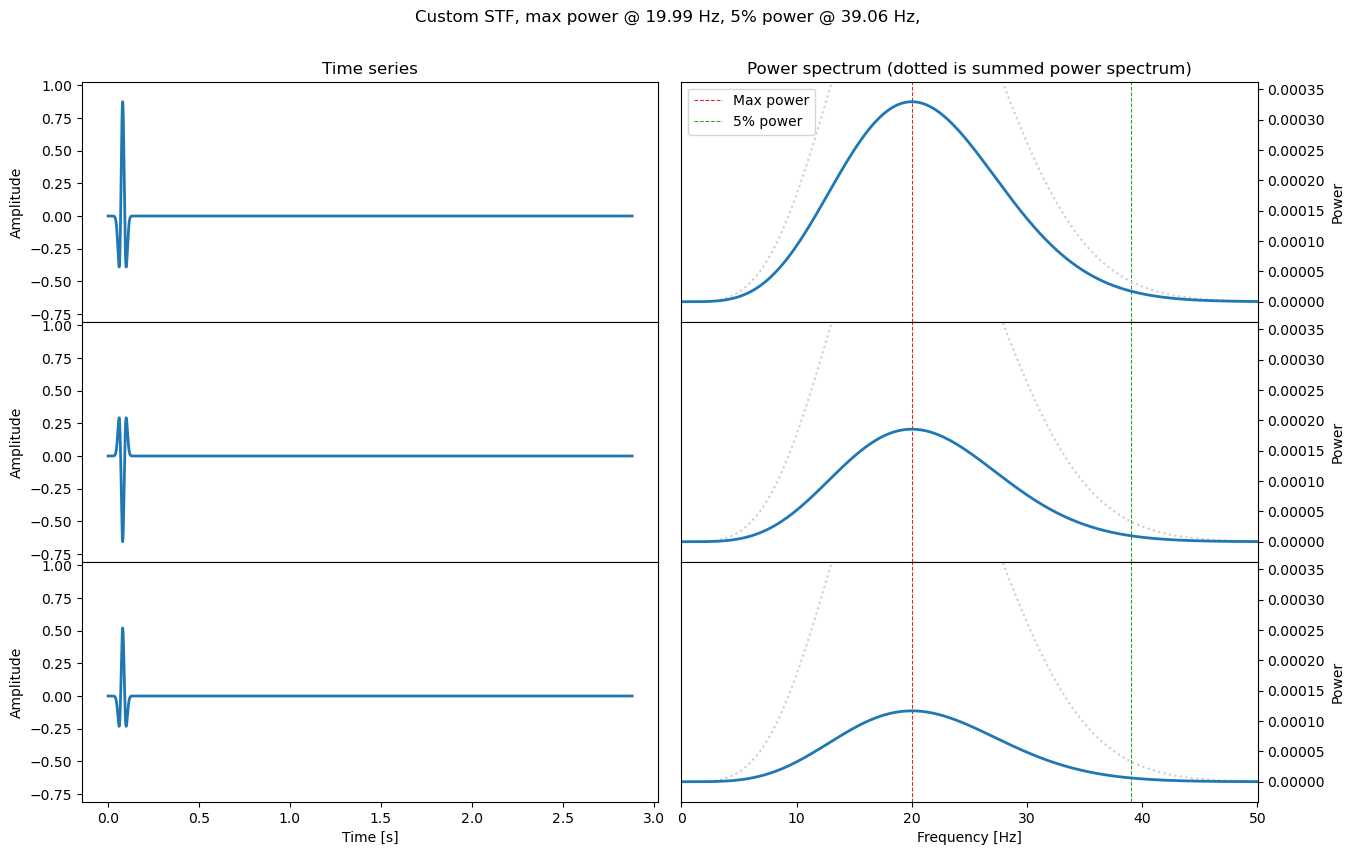

Plotting source index 0 at x = 30.0 m (delay = 0.0800 s, weight = xx:0.8745, yy: 0.6560, xy: 0.5206):


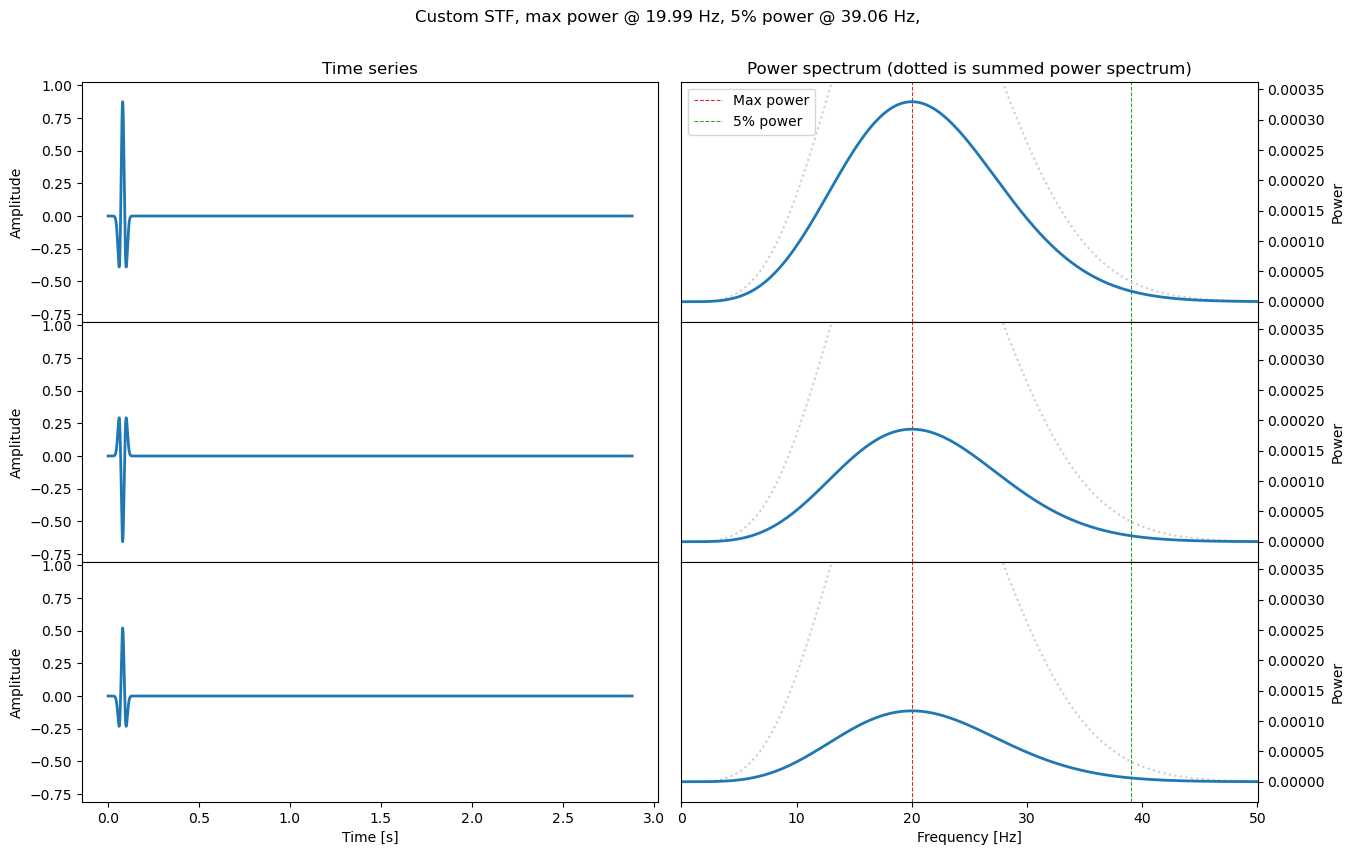

Plotting source index 1 at x = 80.0 m (delay = 0.6356 s, weight = xx:1.4507, yy: 0.5581, xy: 1.4699):


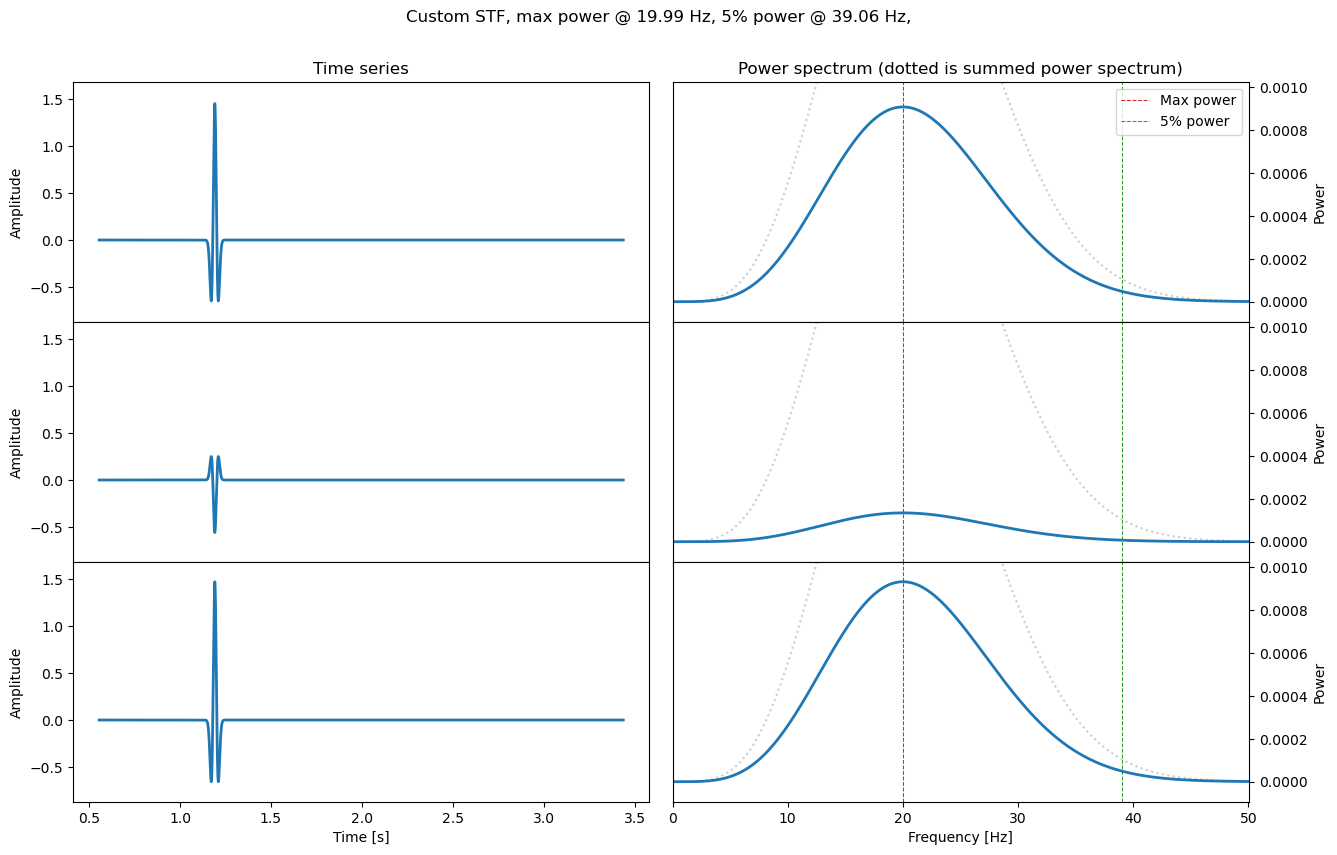

Plotting source index 2 at x = 130.0 m (delay = 1.1911 s, weight = xx:1.2320, yy: 1.3662, xy: 1.3324):


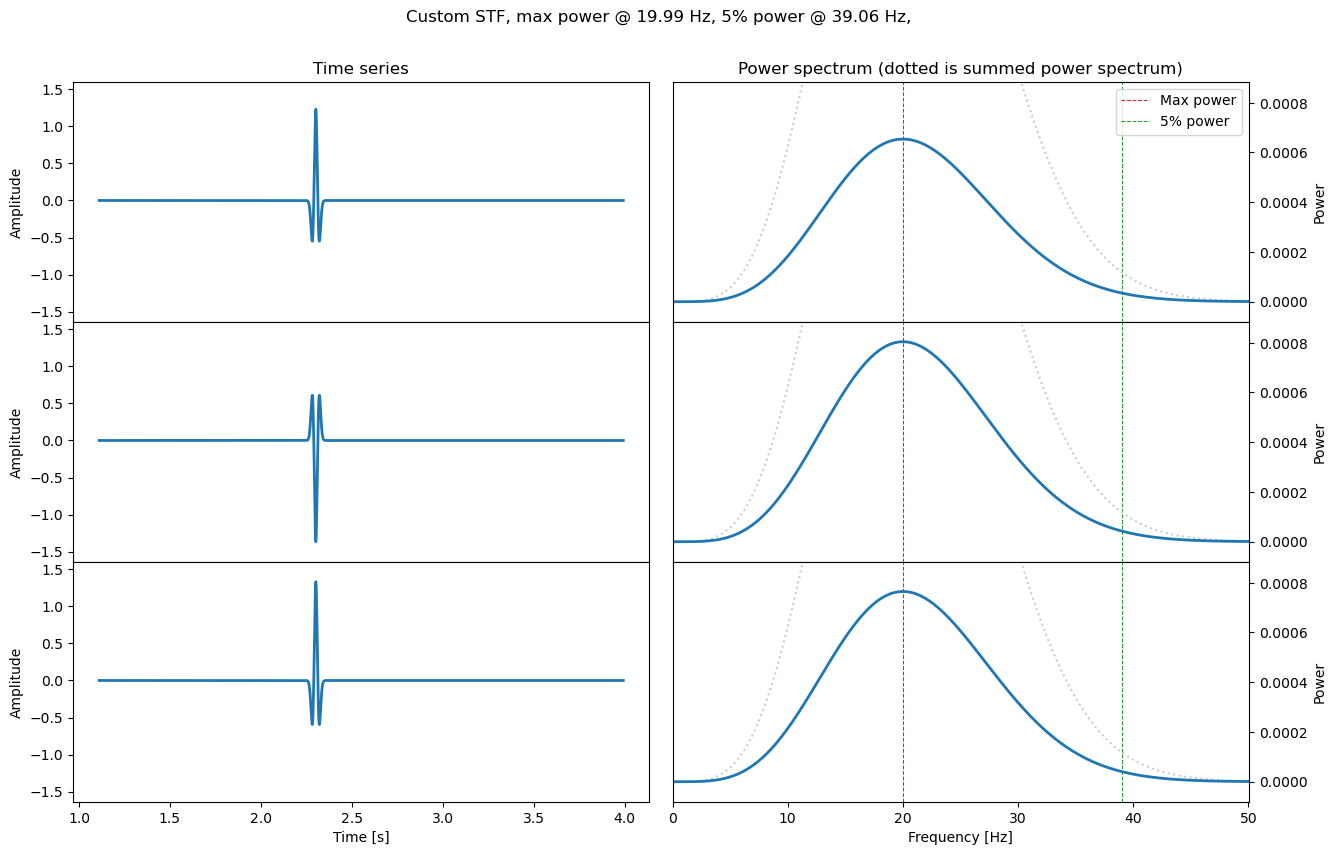

Plotting source index 3 at x = 180.0 m (delay = 1.7467 s, weight = xx:1.0987, yy: 1.1011, xy: 0.7123):


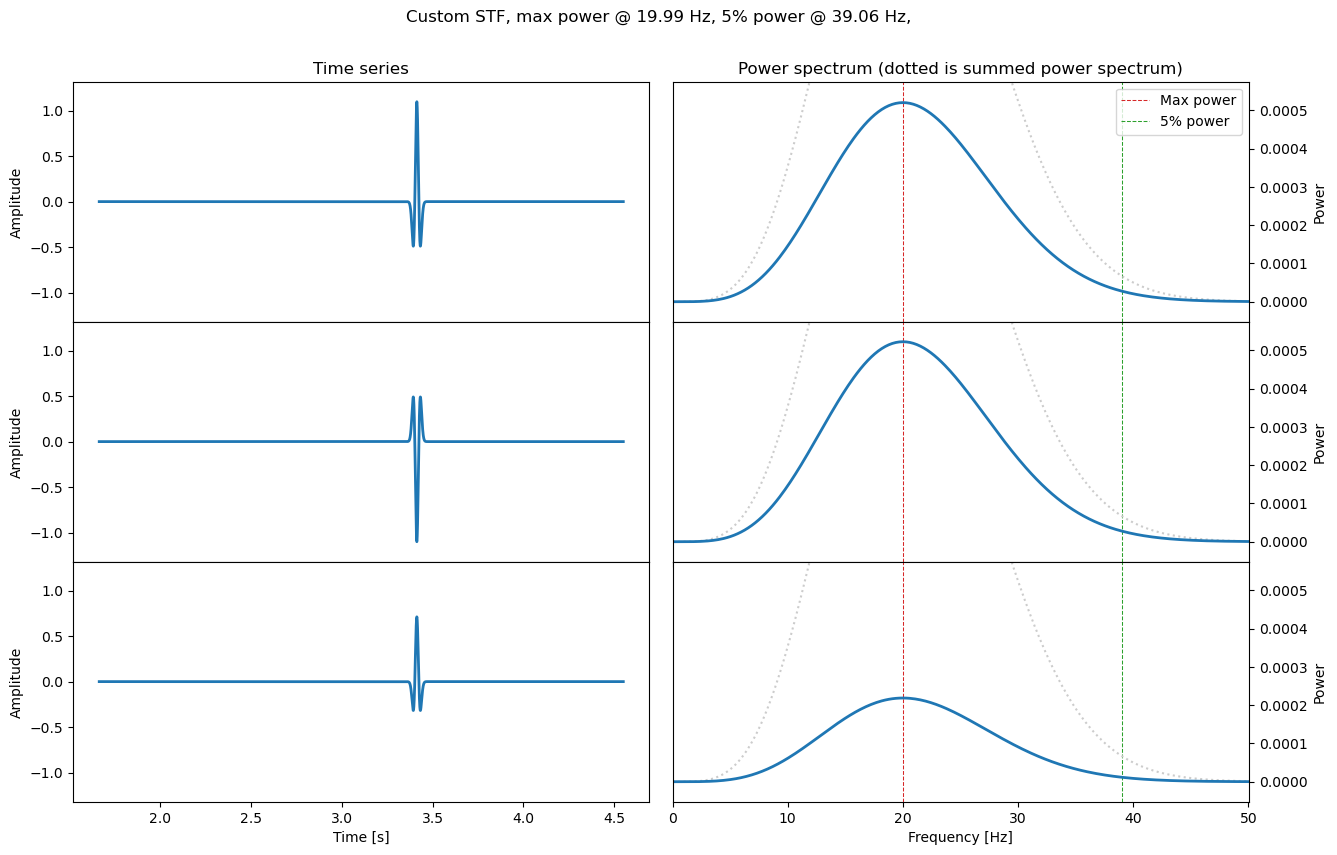

Plotting source index 4 at x = 230.0 m (delay = 2.3022 s, weight = xx:0.6560, yy: 1.2081, xy: 0.6818):


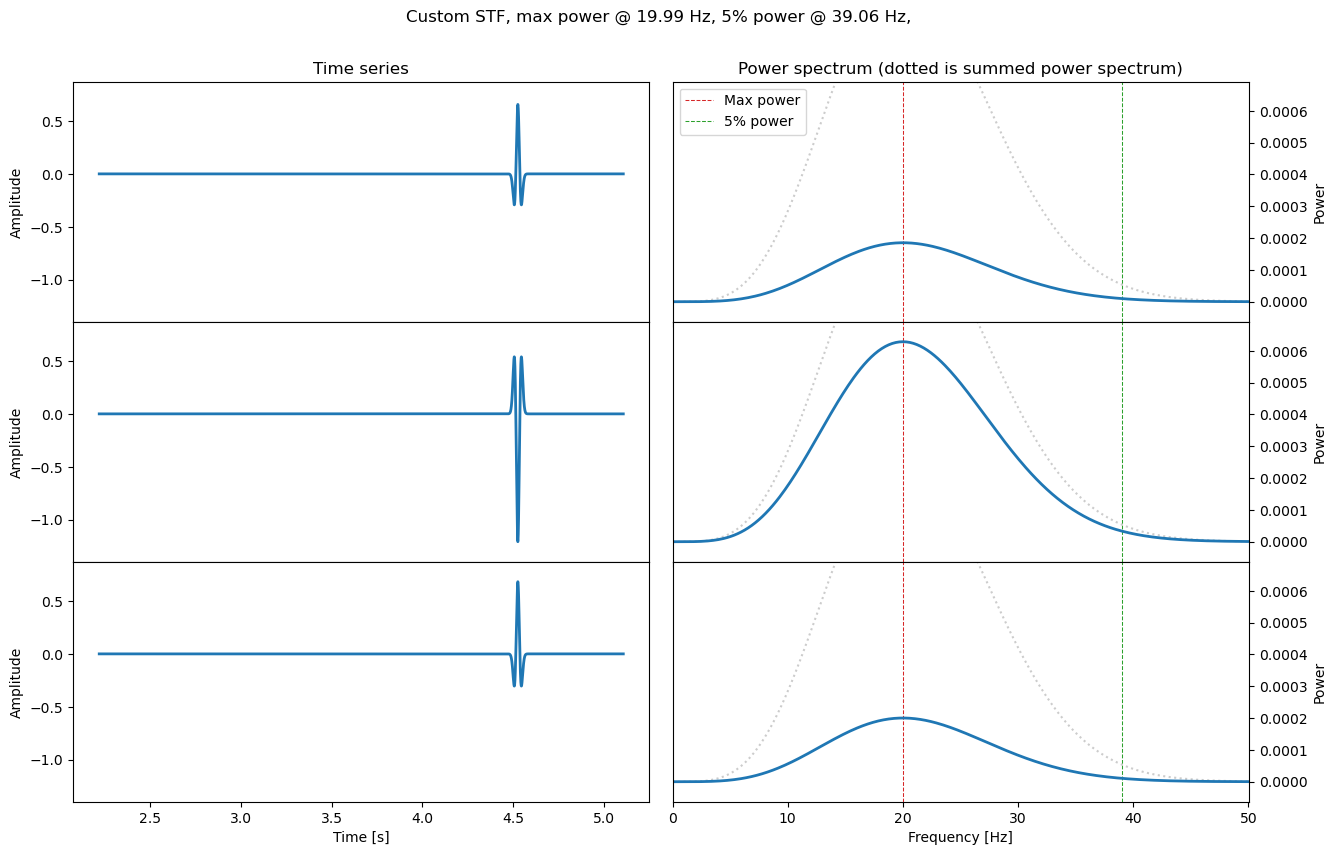


Generated 5 sources.
First source centred at: 0.0800 s
Last  source centred at: 2.3022 s


In [4]:
np.random.seed(42)

# Simulation constants
f0 = 20.0
sampling_rate = 10000.0
dt = 1.0 / sampling_rate

step = 50
x_positions = np.arange(30.0, 270.0, step)
target_vprop = 90.0
delay_between_sources = step / target_vprop
print(f"Time step between sources: {delay_between_sources:.4f} s")

y_src = 2.625

# Pre-delay: shifts ALL sources forward so source 0 has full room
wavelet_half_width = 0.08
pre_delay = wavelet_half_width  # 0.08 s — first wavelet centred at 0.08 s

# Extend t_max to accommodate pre_delay + all source delays + trailing room
last_source_delay = (len(x_positions) - 1) * delay_between_sources
t_max = pre_delay + last_source_delay + wavelet_half_width + 0.5
t_sim = np.arange(0, t_max, dt)
print(f"t_sim length: {len(t_sim)} samples, duration: {t_sim[-1]:.3f} s")

# Base Ricker wavelet on symmetric local time axis
t_local = np.arange(-wavelet_half_width, wavelet_half_width, dt)
wavelet_base = (
    (1.0 - 2.0 * (np.pi * f0 * t_local) ** 2)
    * np.exp(-((np.pi * f0 * t_local) ** 2))
)
half_samples = len(wavelet_base) // 2

base_mxx =  1.0
base_myy = -1.0
base_mxy =  1.0

srcs = []

# create random weight array with elements the same size as number of sources
random_weight_xx = np.random.uniform(0.5, 1.5, size=len(x_positions))
random_weight_yy = np.random.uniform(0.5, 1.5, size=len(x_positions))
random_weight_xy = np.random.uniform(0.5, 1.5, size=len(x_positions))

# combining all weights into one array 
weight_array = np.array([random_weight_xx, random_weight_yy, random_weight_xy]).T

for i, x_src in enumerate(x_positions):
    # Every source gets pre_delay + its propagation delay — no special cases
    center_time = pre_delay + i * delay_between_sources
    center_sample = int(round(center_time * sampling_rate))

    start_idx = center_sample - half_samples
    end_idx = center_sample + half_samples

    wavelet_delayed = np.zeros(len(t_sim))

    if end_idx > 0 and start_idx < len(t_sim):
        sim_start = max(0, start_idx)
        sim_end = min(len(t_sim), end_idx)
        wav_start = max(0, -start_idx)
        wav_end = wav_start + (sim_end - sim_start)
        wavelet_delayed[sim_start:sim_end] = wavelet_base[wav_start:wav_end]

    # Sanity check: full wavelet should be contained
    n_nonzero = np.count_nonzero(wavelet_delayed)
    expected = len(wavelet_base)
    if n_nonzero < expected - 2:
        print(f"  WARNING source {i}: only {n_nonzero}/{expected} samples written — wavelet clipped!")

   
    # stf_vector_array = np.array([
    #     wavelet_delayed * (base_mxx * random_weight_xx),
    #     wavelet_delayed * (base_myy * random_weight_yy),
    #     wavelet_delayed * (base_mxy * random_weight_xy),
    # ])

    stf_vector_array = np.array([
        wavelet_delayed * (base_mxx * weight_array[i, 0]),
        wavelet_delayed * (base_myy * weight_array[i, 1]),
        wavelet_delayed * (base_mxy * weight_array[i, 2]),
    ])

   
    stf_start_time = start_idx * dt  # This tells Salvus when the wavelet actually starts

    stf = sc.stf.Custom.from_array(
        array=stf_vector_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=stf_start_time,  # Use the absolute start time
    )


    
    plotting_steps = np.arange(0, len(x_positions), 5)
    if i in plotting_steps:
        print(f"Source {i} at x={x_src:.1f} m | delay={pre_delay + i*delay_between_sources:.4f} s | weight= xx:{weight_array[i, 0]:.4f},  yy: {weight_array[i, 1]:.4f}, xy: {weight_array[i, 2]:.4f} | stf_start_time={stf_start_time:.6f}s")
        stf.plot()
        display(plt.gcf())
        plt.close()

    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x_src,
        y=y_src,
        mxx=1.0,
        myy=1.0,
        mxy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)


    # Plotting every 100th source for visual inspection of the STF
    plotting_steps = np.arange(0, len(x_positions), 1)
    if i in plotting_steps:
        print(f"Plotting source index {i} at x = {x_src:.1f} m (delay = {pre_delay + i * delay_between_sources:.4f} s, weight = xx:{weight_array[i, 0]:.4f}, yy: {weight_array[i, 1]:.4f}, xy: {weight_array[i, 2]:.4f}):")
        stf.plot()
        fig = plt.gcf()
        display(fig)
        plt.close(fig)


   
print(f"\nGenerated {len(srcs)} sources.")
print(f"First source centred at: {pre_delay:.4f} s")
print(f"Last  source centred at: {pre_delay + (len(srcs)-1)*delay_between_sources:.4f} s")

In [5]:
srcs

[{'location': [30.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260619143933505755ed5709__450457/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [80.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260619143917487359ea5658__450457/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'moment_tensor',
  'spatial_weights': [1.0, 1.0, 1.0]},
 {'location': [130.0, 2.625],
  'source_time_function': {'dataset_name': '/stf',
                           'filename': '/tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260619143955572644d1f22a__450457/custom_stf.h5',
                           'wavelet': 'custom'},
  'spatial_type': 'm

In [6]:
import h5py


h5_path = srcs[0].source_time_function.filename
dataset_name = srcs[0].source_time_function.dataset_name
wavelet_type = srcs[0].source_time_function.wavelet

print(f"Wavelet Type: {wavelet_type}")
print(f"HDF5 File Location: {h5_path}")
print(f"Dataset Name inside HDF5: {dataset_name}\n")

# Open  file to look at the raw custom wavelet data structure
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    
    print("--- Dataset Details ---")
    print("Array Shape (n_components, n_samples):", dset.shape)
    print("Data Type:", dset.dtype)
    
    print("\n--- Meta-Data Attributes Attached by Salvus ---")
    for key, val in dset.attrs.items():
        print(f"  {key}: {val}")
        
    # first 10 numerical values of the actual wavelet array
    print("\nFirst 10 amplitude values of the custom array:")
    print(dset[:10])

    

Wavelet Type: custom
HDF5 File Location: /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__260619143933505755ed5709__450457/custom_stf.h5
Dataset Name inside HDF5: /stf

--- Dataset Details ---
Array Shape (n_components, n_samples): (28823, 3)
Data Type: float64

--- Meta-Data Attributes Attached by Salvus ---
  sampling_rate_in_hertz: 10000.0
  start_time_in_seconds: 0.0

First 10 amplitude values of the custom array:
[[-4.61002390e-10  3.45798935e-10 -2.74419310e-10]
 [-4.89790175e-10  3.67392717e-10 -2.91555716e-10]
 [-5.20332828e-10  3.90302830e-10 -3.09736736e-10]
 [-5.52734592e-10  4.14607467e-10 -3.29024423e-10]
 [-5.87105733e-10  4.40389338e-10 -3.49484414e-10]
 [-6.23562875e-10  4.67735923e-10 -3.71186132e-10]
 [-6.62229359e-10  4.96739739e-10 -3.94202997e-10]
 [-7.03235613e-10  5.27498623e-10 -4.18612649e-10]
 [-7.46719552e-10  5.60116024e-10 -4.44497185e-10]
 [-7.92826994e-10  5.94701321e-10 -4.71943403e-10]]


In [7]:


# Path and dataset pointer form object for first source 
h5_path = srcs[1].source_time_function.filename
dataset_name = srcs[1].source_time_function.dataset_name

# Extract the array and metadata from the HDF5 file
with h5py.File(h5_path, 'r') as f:
    dset = f[dataset_name]
    stf_array = np.squeeze(dset[:]) # Squeeze removes empty dimensions 
    
    # Extract attributes
    sampling_rate = dset.attrs.get('sampling_rate_in_hertz', 10000.0)
    start_time = dset.attrs.get('start_time_in_seconds', 0.0)

# Time axis of soutce 
dt = 1.0 / sampling_rate
time_axis = start_time + (np.arange(len(stf_array)) * dt)


plt.figure(figsize=(10, 4))
plt.plot(time_axis, stf_array, color='crimson', lw=1.5)
plt.xlabel('Simulation Time (seconds)')
plt.ylabel('Amplitude')
plt.title('Custom STF Waveform (Extracted from Salvus HDF5)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:

# Layered model setup: three layers ordered as snow, slab, air (top to bottom).


x_min, x_max = 0.0, 400.0
# Geometry (y-coordinates: higher = higher depth, measured downward):
# Snow: from y=3.0 m (top) to y=2.25 m
# Slab: from y=2.25 m to y=1.5 m  
# Air:  from y=1.5 m to y=0.0 m (bottom)

slab_top = 3.0
slab_bottom = 2.25
wl_top = 2.25
wl_bottom = 1.5
air_top = 1.5
air_bottom = 0.0

# Boundaries from top to bottom -> 3 layers.
# Must be strictly ordered: top to bottom (decreasing y).
layers_x = [
    np.array([x_min, x_max]),  # snow top boundary
    np.array([x_min, x_max]),  # snow-slab interface
    np.array([x_min, x_max]),  # slab-air interface
    np.array([x_min, x_max]),  # air bottom boundary
]
layers_y = [
    np.array([slab_top, slab_top]),      # y = 3.0
    np.array([slab_bottom, slab_bottom]),  # y = 2.25
    np.array([wl_bottom, wl_bottom]),  # y = 1.5
    np.array([air_bottom, air_bottom]),    # y = 0.0
]

# Material parameters by region index [snow, slab, air].
vp = np.array([332.0, 300.0, 300.0]) 
vs = np.array([150.0, 150.0, 0.0])   
rho = np.array([180.0, 180.0, 1.225])

interpolation_styles = ["linear"] * len(layers_x)
splines = sn.toolbox.get_interpolating_splines(layers_x, layers_y, kind=interpolation_styles)

# Maximum frequency for meshing
# Phyiscical frequency of wavelet using fft
n_fft = len(wavelet_base)
fft_vals = np.fft.rfft(wavelet_base)
frequencies = np.fft.rfftfreq(n_fft, d=dt)
amplitude_spectrum = np.abs(fft_vals)

# Finding amplitude
cumulative_amplitude = np.cumsum(amplitude_spectrum)
total_amplitude = cumulative_amplitude[-1]

# Frequency where 95% of spactrum is contained
percentile_95_idx = np.where(cumulative_amplitude >= 0.95 * total_amplitude)[0][0]
max_frequency_source = frequencies[percentile_95_idx]
max_frequency = float(max_frequency_source)

print(f"Base Ricker Center Frequency (f0): {f0} Hz")
print(f"95th Percentile Source Frequency Content: {max_frequency:.1f} Hz")



# One per layer pair; last value keeps meshing stable above acoustic air.
slowest_velocities = np.array([150.0, 150.0,  150.0])

# calculating the wavelength of the center freqnecy (lambda = v / f)
wavelengths = slowest_velocities[0] / 20
print(f"Calculated minimum thickness for ABC: {wavelengths} m")
# Absorbing boundary should be at least 1 wavelength of the max frequency




mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2.5,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=(["x0", "x1", "y0"], 2*wavelengths),
)
mesh = np.sum(mesh)
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)

nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    idx = np.where(mesh.elemental_fields["region"] == _i)
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

mesh_3layer = sn.toolbox.detect_fluid(mesh)
print("Three-layer mesh built.")
print(f"  SLab: y = [{slab_top:.2f}, {slab_bottom:.2f}] m, vs={vs[0]:.0f} m/s")
print(f"  Weak layer: y = [{wl_top:.2f}, {wl_bottom:.2f}] m, vs={vs[1]:.0f} m/s")
print(f"  Air layer:  y = [{air_top:.2f}, {air_bottom:.2f}] m, vs={vs[2]:.0f} m/s")


Base Ricker Center Frequency (f0): 20.0 Hz
95th Percentile Source Frequency Content: 37.5 Hz
Calculated wavelengths for each layer at 95th percentile frequency: 7.5
Three-layer mesh built.
  SLab: y = [3.00, 2.25] m, vs=150 m/s
  Weak layer: y = [2.25, 1.50] m, vs=150 m/s
  Air layer:  y = [1.50, 0.00] m, vs=0 m/s


In [9]:
# Initialize simulation object, pass multiple sources
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

# physics parameters 
sim.physics.wave_equation.end_time_in_seconds = 3.0
sim.physics.wave_equation.start_time_in_seconds = 0.05

sim.output.volume_data.format = "hdf5"
sim.output.volume_data.fields = ["displacement", "velocity"]
sim.output.volume_data.filename = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 50


moving_source_output_folder = str(pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources")

print(f"Launching simulation. Outputs will be copied to: {moving_source_output_folder}")

# Launchg
salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True, 
)

print("Run finished successfully!")

Launching simulation. Outputs will be copied to: simulation_wavefield_custom_stf_weighted_denser/custom_job_moving_source_all_sources
SalvusJob `job_2606191145110819_92c2e7bb93` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/9844 [00:00<?, ?it/s]

* Downloaded 53.6 MB of results to `simulation_wavefield_custom_stf_weighted_denser/custom_job_moving_source_all_sources`.
* Total run time: 4.25 seconds.
* Pure simulation time: 3.82 seconds.
Run finished successfully!


In [10]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(
        f"Missing output file: {vol_file}. Re-run the launch cell and verify the job completed."
    )

vel_wo = wavefield_output.WavefieldOutput.from_file(
    vol_file,
    "velocity",
    "volume",
)

vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, 400, 1601), np.linspace(0, 3, 101)],
)

print(f"Loaded velocity from {vol_file}")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/161701 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/80050 [00:00<?, ?it/s]

[2026-06-19 11:45:54,174] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 80050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/6 [00:00<?, ?it/s]

Loaded velocity from simulation_wavefield_custom_stf_weighted_denser/custom_job_moving_source_all_sources/volume_data_output.h5
Shape: ('t', 'c', 'x', 'y')
<xarray.DataArray (t: 198, c: 2, x: 1601, y: 101)> Size: 256MB
array([[[[           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [           nan,            nan,            nan, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[           nan,        

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: 0.05 -> 3.001798049573344
vx shape: (198, 1601)
vy shape: (198, 1601)


/tmp/ipykernel_443869/1095561471.py:56: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_443869/1095561471.py:78: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


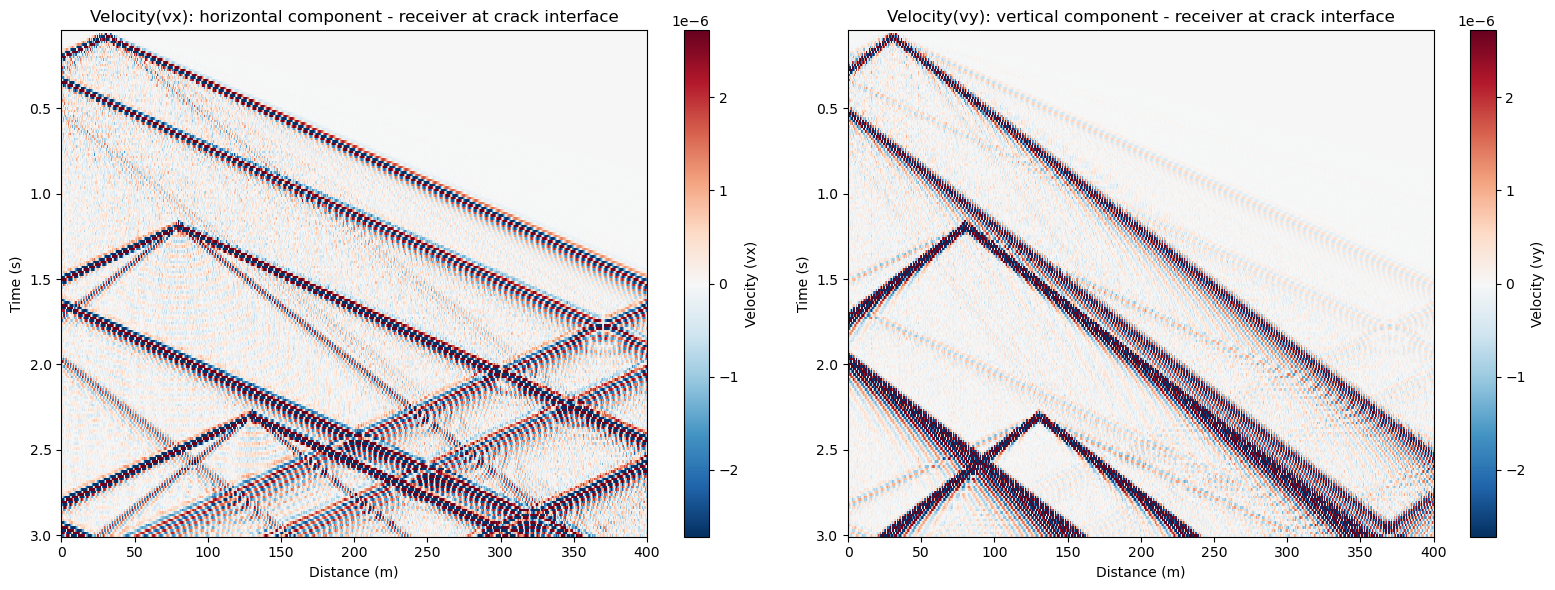

In [11]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select both components at y receiver line
sg_vx = vel_2d_layered.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 400)
axes[0].set_title("Velocity(vx): horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 400)
axes[1].set_title("Velocity(vy): vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)